In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from phd_project.scripts import metaregression_analysis as mra
from phd_project.scripts.femap695_records import femap695_record_tags
from phd_project.config import config

cfg = config.load_config()

In [ ]:
# Number of bootstrap replications. One record sample is drawn per replicate and
# reused at every structure - see 1.1. Dropped to 10 to re-save every output in the merged
# one-file-per-output layout quickly; raise it back before reading anything into a result.
K_SAMPLES = 10

# Storey counts to bootstrap. Only the 3s group IDAs are complete; append 5 once the
# 5s runs finish - nothing else needs to change.
N_STOREYS = [3, 5]

# The IM the fragilities are expressed in (selects the collapse-IML table).
IM_TAG = "AvgSA_03"

# Reload a previously saved bootstrap instead of refitting it, when every file it needs
# is already on disk. The fits are deterministic, so this only trades ~5 min of MLE for a
# read. Set False to force a recompute (after changing K_SAMPLES, the seed, the screen,
# or the underlying analysis results).
REUSE_SAVED = False

BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]
SAMPLES_CSV = BOOTSTRAP_PTH / "femap695_bootstrapped_indices.csv"

# IDA arm: per-record collapse capacities (nb 053) and the group fragility summary,
# which also carries each group's member sites.
_iml_stem = Path(cfg["proc_data"]["wp1_groups_femap695_collapse_imls"])
COLLAPSE_IML_CSV = _iml_stem.with_name(f"{_iml_stem.stem}_{IM_TAG}.csv")
GROUP_FC_SUMMARY = cfg["proc_data"]["wp1_groups_femap695_fc_summary"]

# IDA collapse-bracket arms (nb 053 section 10). The IDA brackets each record's collapse
# between the highest intensity that ran and the lowest that collapsed; the arm above
# uses the lower bound, these two use the upper bound and the bracket's geometric mean.
# Same estimator, same record sample - only the capacity table differs.
BRACKET_VARIANTS = ["ub", "avg"]
BRACKET_ARM = {v: f"ida_femap695_{v}" for v in BRACKET_VARIANTS}
BRACKET_IM_LABEL = {v: f"{IM_TAG}_{v}" for v in BRACKET_VARIANTS}
BRACKET_IML_CSV = {v: _iml_stem.with_name(f"{_iml_stem.stem}_{IM_TAG}_{v}.csv")
                   for v in BRACKET_VARIANTS}
BRACKET_FC_SUMMARY = Path(GROUP_FC_SUMMARY).with_name(
    "group_femap695_bracket_collapsefragility_summary.csv")

# MSA arm: per-record collapse flags at each stripe (nb 061) and the group MSA fits.
_flag_stem = Path(cfg["proc_data"]["wp1_groups_msa_femap695_collapse_flags"])
COLLAPSE_FLAGS_CSV = _flag_stem.with_name(f"{_flag_stem.stem}_{IM_TAG}.csv")
GROUP_MSA_FC_SUMMARY = cfg["proc_data"]["wp1_groups_msa_femap695_fc_summary"]

# Site-specific MSA arm: one fragility JSON per structure (nb 060). There is no summary
# CSV for this arm, so those files are also the only source of its published fits.
SITE_FC_ROOT = cfg["proc_data"]["wp1_sites_fragility_curves"]
SITES = list(range(60))
SITE_MSA_N_RECORDS = 30    # GCIM selects 30 records at every stripe (nb 017/050)

## 1.0 Bootstrap FEMA P695 Dataset

### 1.1 Bootstrap indices

Because FEMAP695 is a fixed record set the bootstrapping only needs to be conducted once and then the same sampled records are used across all of the analyses. That way it mimics the same record set being used at all sites. (The whole idea of a fixed record set).
The sampling is based on the index of the file in the folder (i.e. 0-21). Using this index the collapse/non-collapse can be determined from the msa_log file and teh capacities can be extracted from teh ida_log file. 

In [4]:
record_tags = femap695_record_tags(cfg["raw_data"]["femap695_records"])
print(f"{len(record_tags)} records: {record_tags[0]} (tag 0) ... {record_tags[-1]} "
      f"(tag {len(record_tags) - 1})")

samples = mra.draw_record_samples(record_tags, K_SAMPLES, seed=1)
np.savetxt(SAMPLES_CSV, samples, delimiter=",", fmt="%s")

samples

22 records: fema_p695_120111 (tag 0) ... fema_p695_121711 (tag 21)


array([['fema_p695_120911', 'fema_p695_120921', 'fema_p695_121221',
        'fema_p695_121511', 'fema_p695_120111', 'fema_p695_120521',
        'fema_p695_121411', 'fema_p695_121511', 'fema_p695_120621',
        'fema_p695_120711', 'fema_p695_121421', 'fema_p695_120821',
        'fema_p695_120711', 'fema_p695_121411', 'fema_p695_120621',
        'fema_p695_120821', 'fema_p695_121111', 'fema_p695_121011',
        'fema_p695_120121', 'fema_p695_120111', 'fema_p695_121421',
        'fema_p695_121221'],
       ['fema_p695_121411', 'fema_p695_120921', 'fema_p695_121321',
        'fema_p695_120721', 'fema_p695_120821', 'fema_p695_121321',
        'fema_p695_120411', 'fema_p695_120711', 'fema_p695_120411',
        'fema_p695_120821', 'fema_p695_121711', 'fema_p695_120411',
        'fema_p695_120811', 'fema_p695_120811', 'fema_p695_121421',
        'fema_p695_120611', 'fema_p695_120921', 'fema_p695_120621',
        'fema_p695_120111', 'fema_p695_121221', 'fema_p695_120121',
        'fema_p695_

In [5]:
# Reload the drawn sample, so 1.2 can be re-run without redrawing it. The checks guard
# against the sample on disk having been drawn from a different record set.
samples = np.loadtxt(SAMPLES_CSV, delimiter=",", dtype=str)
assert samples.shape == (K_SAMPLES, len(record_tags))
assert set(np.unique(samples)) <= set(record_tags)
samples.shape

(10, 22)

### 1.2 IDA-FEMAP695 fragility parameters

Each replicate is a resample (with replacement) of the 22 FEMA P695 records. The IDA already gives a **collapse capacity per record** for every design group (nb 053, `group_femap695_collapse_imls_{IM}.csv`, in g), so a replicate is formed by looking those capacities up for the sampled record tags and refitting the lognormal by moments - the same fit `fragility_from_ida` performs. This is a non-parametric bootstrap of the real capacities, not a parametric draw from the fitted curve.

The IDA is run **per design group**, not per site, because the record set is fixed and the analysis therefore depends only on the structure. Results are written out both ways: `_by_group` (25 columns for 3s, no duplication) and `_by_site` (60 columns, sites sharing a design carrying identical columns) so the IDA arm lines up column-by-column with the per-site MSA arm.

In [6]:
record_tags = femap695_record_tags(cfg["raw_data"]["femap695_records"])

collapse_imls = mra.load_group_collapse_imls(COLLAPSE_IML_CSV, N_STOREYS, record_tags)
group_sites = mra.load_group_site_map(GROUP_FC_SUMMARY, N_STOREYS)

for n in N_STOREYS:
    sites = sorted(s for ss in group_sites[n].values() for s in ss)
    print(f"[{n}s] {collapse_imls[n].shape[0]} groups x {collapse_imls[n].shape[1]} records"
          f"  ->  {len(sites)} sites, contiguous from 0: {sites == list(range(len(sites)))}")

[3s] 25 groups x 22 records  ->  60 sites, contiguous from 0: True


#### Fit each replicate

The moment fit is cheap, so this runs in seconds either way - but it goes through the same reuse switch as the other two arms so all three behave alike. Only the `by_group` frames are read back; the `by_site` versions are re-derived from them and the stats recomputed below, so a stale or half-written file cannot leave the two views disagreeing.

In [7]:
theta_by_group, beta_by_group = {}, {}
theta_by_site, beta_by_site = {}, {}

for n in N_STOREYS:
    saved = REUSE_SAVED and mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "ida_femap695", ("theta", "beta"), n, IM_TAG, "by_group",
        k_samples=K_SAMPLES)
    if saved:
        theta_by_group[n], beta_by_group[n] = saved["theta"], saved["beta"]
        source = "loaded"
    else:
        theta_by_group[n], beta_by_group[n] = mra.bootstrap_ida_group_fragilities(
            collapse_imls[n], samples, record_tags)
        source = "computed"

    theta_by_site[n] = mra.expand_groups_to_sites(theta_by_group[n], group_sites[n])
    beta_by_site[n] = mra.expand_groups_to_sites(beta_by_group[n], group_sites[n])
    print(f"[{n}s] theta/beta ({source}): {theta_by_group[n].shape} by group, "
          f"{theta_by_site[n].shape} by site")

theta_by_site[N_STOREYS[0]].head()

[3s] theta/beta (computed): (10, 25) by group, (10, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.391423,0.387744,0.387744,0.372802,0.391423,0.387744,0.387744,0.472452,0.391423,0.357241,...,0.454609,0.779126,0.628028,0.802919,0.601475,0.580687,0.563242,0.601475,0.439915,0.809067
1,0.398267,0.387259,0.387259,0.382181,0.398267,0.387259,0.387259,0.476347,0.398267,0.374639,...,0.459459,0.750604,0.608054,0.754943,0.579598,0.566046,0.546332,0.579598,0.443516,0.753105
2,0.435651,0.405338,0.405338,0.406024,0.435651,0.405338,0.405338,0.485744,0.435651,0.383947,...,0.475827,0.786144,0.637619,0.794371,0.603220,0.583744,0.574249,0.603220,0.451158,0.788532
3,0.355026,0.372561,0.372561,0.353900,0.355026,0.372561,0.372561,0.448561,0.355026,0.349773,...,0.425912,0.775437,0.609491,0.779273,0.574761,0.574974,0.544719,0.574761,0.418516,0.782777
4,0.402683,0.377302,0.377302,0.390117,0.402683,0.377302,0.377302,0.463900,0.402683,0.354894,...,0.427929,0.743444,0.585569,0.775891,0.551998,0.559461,0.524166,0.551998,0.408414,0.775976


#### Summary statistics

In [8]:
theta_stats_by_group = {n: mra.bootstrap_stats_frame(theta_by_group[n]) for n in N_STOREYS}
beta_stats_by_group = {n: mra.bootstrap_stats_frame(beta_by_group[n]) for n in N_STOREYS}
theta_stats_by_site = {n: mra.bootstrap_stats_frame(theta_by_site[n]) for n in N_STOREYS}
beta_stats_by_site = {n: mra.bootstrap_stats_frame(beta_by_site[n]) for n in N_STOREYS}

theta_stats_by_site[N_STOREYS[0]].head()

,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,10.0,0.355026,0.435651,0.393621,0.394845,0.000497,0.023505,0.358878,0.362730,0.373410,0.412049,0.425585,0.430618,0.109731,-0.603114
1,10.0,0.372561,0.405968,0.386948,0.384849,0.000153,0.013017,0.372937,0.373313,0.374706,0.403575,0.405684,0.405826,0.449980,-1.347122
2,10.0,0.372561,0.405968,0.386948,0.384849,0.000153,0.013017,0.372937,0.373313,0.374706,0.403575,0.405684,0.405826,0.449980,-1.347122
3,10.0,0.353900,0.406024,0.380367,0.379059,0.000336,0.019334,0.354481,0.355061,0.359039,0.401977,0.404238,0.405131,-0.009948,-1.405812
4,10.0,0.355026,0.435651,0.393621,0.394845,0.000497,0.023505,0.358878,0.362730,0.373410,0.412049,0.425585,0.430618,0.109731,-0.603114


#### Check against the fitted curves

The bootstrap median should sit on top of the fit it resamples. The dispersion comes out a few percent low: the moment fit of a resample is biased downwards at 22 records, which is exactly the small-sample effect the downstream models have to account for.

In [9]:
_summary = pd.read_csv(GROUP_FC_SUMMARY, header=[0, 1], index_col=0)

for n in N_STOREYS:
    groups = theta_by_group[n].columns
    check = pd.DataFrame({
        "theta_fit": _summary.loc[groups, (IM_TAG, "median")].astype(float),
        "theta_boot": theta_by_group[n].mean(),
        "beta_fit": _summary.loc[groups, (IM_TAG, "dispersion")].astype(float),
        "beta_boot": beta_by_group[n].mean()})
    check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
    check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
    print(f"[{n}s] deviation of the bootstrap mean from the fit, over {len(groups)} groups")
    print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")

_g = theta_by_group[N_STOREYS[0]].columns[0]
print(f"bootstrap cloud for {_g}")
mra.print_stats([mra.get_stats(theta_by_group[N_STOREYS[0]][_g]),
                 mra.get_stats(beta_by_group[N_STOREYS[0]][_g])],
                headings=["theta", "beta"])

[3s] deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min         -0.56       -4.41
mean         0.45        0.86
max          1.58        8.25 

bootstrap cloud for group_3s_00
Stat               theta        beta
------------------------------------
N_obs             10.000      10.000
min                0.355       0.175
max                0.436       0.247
mean               0.394       0.213
median             0.395       0.210
variance       4.972e-04   5.247e-04
std                0.024       0.024
2.5pc              0.359       0.178
5pc                0.363       0.181
16pc               0.373       0.191
84pc               0.412       0.238
95pc               0.426       0.245
97.5pc             0.431       0.246
skewness           0.110       0.031
kurtosis      -6.031e-01  -1.210e+00



#### Save

In [10]:
_frames = {"theta": (theta_by_group, theta_by_site),
           "beta": (beta_by_group, beta_by_site),
           "theta_stats": (theta_stats_by_group, theta_stats_by_site),
           "beta_stats": (beta_stats_by_group, beta_stats_by_site)}

# One file per output, every storey count inside it: the replicate clouds carry
# (unit, n_storeys) on their columns, the stats frames the same pair on their rows. The
# filename no longer names a storey count, so adding 5s does not add a parallel file set.
for _name, (_by_group, _by_site) in _frames.items():
    _stack = (mra.stack_unit_frames if _name.endswith("_stats")
              else mra.stack_cloud_frames)
    for _scope, _frames_n in [("by_group", _by_group), ("by_site", _by_site)]:
        _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
        out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "ida_femap695", _name, IM_TAG, _scope)
        _merged.to_csv(out)
        print(f"wrote {out.name}  {_merged.shape}")


wrote ida_femap695_bootstrap_theta_AvgSA_03_by_group.csv  (10, 25)
wrote ida_femap695_bootstrap_theta_AvgSA_03_by_site.csv  (10, 60)
wrote ida_femap695_bootstrap_beta_AvgSA_03_by_group.csv  (10, 25)
wrote ida_femap695_bootstrap_beta_AvgSA_03_by_site.csv  (10, 60)
wrote ida_femap695_bootstrap_theta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote ida_femap695_bootstrap_theta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote ida_femap695_bootstrap_beta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote ida_femap695_bootstrap_beta_stats_AvgSA_03_by_site.csv  (60, 15)


### 1.3 MSA-FEMAP695 fragility parameters

The MSA runs the **same fixed record set at every stripe**, so a record resample moves every stripe of a group coherently: replicate `k`'s collapse count at a stripe is simply how many of the 22 sampled records collapsed there. nb 061 exports those per-record outcomes as `group_msa_femap695_collapse_flags_{IM}.csv`, a `(group, stripe_iml) x record` table of 0/1 flags on the same record tags the IDA table uses, so **the same `samples` array drives both arms** and replicate `k` means the same 22 records in each. Each replicate is refitted with the Baker (2015) binomial MLE - the fit `fragility_from_msa` performs.

Unlike the moment fit, that MLE can fail to have an interior maximum. A resampled stripe profile that is flat - every stripe zero, every stripe full, or every stripe the same fraction - says nothing about *where* the fragility sits, and the optimiser answers by pushing theta and beta off together into a horizontal line through the stripe range (positive and finite, so a finiteness check alone will not catch it). `mra.msa_counts_degenerate` screens those out before the fit and `mra.msa_fit_ok` catches any runaway after it. A merely **non-monotonic** profile is not degenerate - that is ordinary sampling noise and gets fitted normally.

Rejected replicates are left as `NaN` rather than dropped, so row `k` still means the same record sample in every column and in the IDA arm; the boolean mask is saved alongside, and `get_stats` runs on the finite values so `N_obs` reports how many replicates actually stand behind each row.

In [11]:
collapse_flags = mra.load_group_collapse_flags(COLLAPSE_FLAGS_CSV, N_STOREYS, record_tags)

# The MSA summary is a flat, single-header CSV indexed by group (unlike the IDA summary's
# two-row header); nb 061's `well_defined` flags groups whose stripes bracket the median.
msa_summary = pd.read_csv(GROUP_MSA_FC_SUMMARY, index_col=0)

for n in N_STOREYS:
    stripes = collapse_flags[n].groupby(level="group").size()
    groups = msa_summary.index.str.startswith(f"group_{n}s_")
    print(f"[{n}s] {stripes.size} groups x {stripes.min()}-{stripes.max()} stripes, "
          f"{collapse_flags[n].shape[1]} records; "
          f"well_defined: {msa_summary.loc[groups, 'well_defined'].all()}")

[3s] 25 groups x 4-7 stripes, 22 records; well_defined: True

#### Fit each replicate

Refitting the 25,000 replicates takes about five minutes, and the fits are deterministic given `samples` and the flags table. So when a previous run's files are already on disk and `REUSE_SAVED` is set, this loads them instead. Only the three `by_group` frames are read - the `by_site` versions are re-derived from them and the stats are recomputed below, so a stale or half-written file cannot leave the two views disagreeing.

In [12]:
msa_theta_by_group, msa_beta_by_group, msa_fit_ok_by_group = {}, {}, {}
msa_theta_by_site, msa_beta_by_site = {}, {}

for n in N_STOREYS:
    saved = REUSE_SAVED and mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "msa_femap695", ("theta", "beta", "fit_ok"), n, IM_TAG,
        "by_group", k_samples=K_SAMPLES)
    if saved:
        msa_theta_by_group[n] = saved["theta"]
        msa_beta_by_group[n] = saved["beta"]
        msa_fit_ok_by_group[n] = saved["fit_ok"]
        source = "loaded"
    else:
        (msa_theta_by_group[n], msa_beta_by_group[n],
         msa_fit_ok_by_group[n]) = mra.bootstrap_msa_group_fragilities(
            collapse_flags[n], samples, record_tags, msa_summary)
        source = "computed"

    msa_theta_by_site[n] = mra.expand_groups_to_sites(msa_theta_by_group[n], group_sites[n])
    msa_beta_by_site[n] = mra.expand_groups_to_sites(msa_beta_by_group[n], group_sites[n])
    print(f"[{n}s] theta/beta ({source}): {msa_theta_by_group[n].shape} by group, "
          f"{msa_theta_by_site[n].shape} by site")

msa_theta_by_site[N_STOREYS[0]].head()

[3s] theta/beta (computed): (10, 25) by group, (10, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.414458,0.392391,0.392391,0.400858,0.414458,0.392391,0.392391,0.484116,0.414458,0.379353,...,0.475370,0.842696,0.652881,0.872271,0.623178,0.613104,0.607647,0.623178,0.467633,0.875295
1,0.415574,0.395617,0.395617,0.398128,0.415574,0.395617,0.395617,0.493345,0.415574,0.402774,...,0.480418,0.771883,0.642815,0.808881,0.599265,0.595640,0.566675,0.599265,0.470055,0.810991
2,0.443190,0.414162,0.414162,0.413526,0.443190,0.414162,0.414162,0.511799,0.443190,0.417444,...,0.499446,0.832896,0.673940,0.861418,0.642026,0.616963,0.606995,0.642026,0.477341,0.864245
3,0.375369,0.383277,0.383277,0.373726,0.375369,0.383277,0.383277,0.469584,0.375369,0.378232,...,0.445784,0.823457,0.617981,0.837219,0.587504,0.593638,0.572987,0.587504,0.441343,0.839598
4,0.417951,0.385258,0.385258,0.412623,0.417951,0.385258,0.385258,0.498416,0.417951,0.379868,...,0.444347,0.772446,0.598558,0.828447,0.565248,0.566540,0.557347,0.565248,0.429200,0.830755


#### Screening report

How many replicates each group lost to a degenerate stripe profile or a runaway fit. Record resampling is much tamer than redrawing binomial counts stripe-by-stripe, so this is expected to reject nothing - but it is what would surface a group whose stripes stop bracketing its median.

In [13]:
for n in N_STOREYS:
    ok = msa_fit_ok_by_group[n]
    rejected = (~ok).sum()
    print(f"[{n}s] {int(rejected.sum())} of {ok.size} replicate fits rejected "
          f"({100 * rejected.sum() / ok.size:.2f}%)")
    print(f"      usable replicates per group: min {int(ok.sum().min())}, "
          f"mean {ok.sum().mean():.1f}, max {int(ok.sum().max())}")
    if rejected.any():
        print(rejected[rejected > 0].to_string())

[3s] 0 of 250 replicate fits rejected (0.00%)
      usable replicates per group: min 10, mean 10.0, max 10


#### Summary statistics

In [14]:
msa_theta_stats_by_group = {n: mra.bootstrap_stats_frame(msa_theta_by_group[n])
                            for n in N_STOREYS}
msa_beta_stats_by_group = {n: mra.bootstrap_stats_frame(msa_beta_by_group[n])
                           for n in N_STOREYS}
msa_theta_stats_by_site = {n: mra.bootstrap_stats_frame(msa_theta_by_site[n])
                           for n in N_STOREYS}
msa_beta_stats_by_site = {n: mra.bootstrap_stats_frame(msa_beta_by_site[n])
                          for n in N_STOREYS}

msa_theta_stats_by_site[N_STOREYS[0]].head()

,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,10.0,0.375369,0.443190,0.412341,0.415016,0.000393,0.020887,0.379124,0.382879,0.395067,0.432769,0.438744,0.440967,-0.211737,-0.832095
1,10.0,0.383277,0.420364,0.395638,0.389032,0.000169,0.013688,0.383722,0.384168,0.385429,0.411605,0.417573,0.418969,0.799200,-0.951369
2,10.0,0.383277,0.420364,0.395638,0.389032,0.000169,0.013688,0.383722,0.384168,0.385429,0.411605,0.417573,0.418969,0.799200,-0.951369
3,10.0,0.373726,0.424202,0.401551,0.399493,0.000249,0.016645,0.376081,0.378436,0.387417,0.418880,0.423700,0.423951,-0.092296,-1.040777
4,10.0,0.375369,0.443190,0.412341,0.415016,0.000393,0.020887,0.379124,0.382879,0.395067,0.432769,0.438744,0.440967,-0.211737,-0.832095


#### Check against the fitted curves

Same check as the IDA arm: the bootstrap mean should sit on the fit it resamples, with the dispersion a little low from the small-sample bias at 22 records.

In [15]:
for n in N_STOREYS:
    groups = msa_theta_by_group[n].columns
    check = pd.DataFrame({
        "theta_fit": msa_summary.loc[groups, "median"],
        "theta_boot": msa_theta_by_group[n].mean(),
        "beta_fit": msa_summary.loc[groups, "dispersion"],
        "beta_boot": msa_beta_by_group[n].mean()})
    check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
    check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
    print(f"[{n}s] deviation of the bootstrap mean from the fit, over {len(groups)} groups")
    print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")

_g = msa_theta_by_group[N_STOREYS[0]].columns[0]
print(f"bootstrap cloud for {_g}")
mra.print_stats([mra.get_stats(msa_theta_by_group[N_STOREYS[0]][_g].dropna()),
                 mra.get_stats(msa_beta_by_group[N_STOREYS[0]][_g].dropna())],
                headings=["theta", "beta"])

[3s] deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min         -0.36       -7.43
mean         0.62        4.05
max          1.84       20.66 

bootstrap cloud for group_3s_00
Stat               theta        beta
------------------------------------
N_obs             10.000      10.000
min                0.375       0.169
max                0.443       0.258
mean               0.412       0.206
median             0.415       0.200
variance       3.926e-04   8.472e-04
std                0.021       0.031
2.5pc              0.379       0.170
5pc                0.383       0.172
16pc               0.395       0.178
84pc               0.433       0.239
95pc               0.439       0.252
97.5pc             0.441       0.255
skewness      -2.117e-01   4.555e-01
kurtosis      -8.321e-01  -1.130e+00



#### Save

In [16]:
_msa_frames = {"theta": (msa_theta_by_group, msa_theta_by_site),
               "beta": (msa_beta_by_group, msa_beta_by_site),
               "theta_stats": (msa_theta_stats_by_group, msa_theta_stats_by_site),
               "beta_stats": (msa_beta_stats_by_group, msa_beta_stats_by_site)}

for _name, (_by_group, _by_site) in _msa_frames.items():
    _stack = (mra.stack_unit_frames if _name.endswith("_stats")
              else mra.stack_cloud_frames)
    for _scope, _frames_n in [("by_group", _by_group), ("by_site", _by_site)]:
        _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
        out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "msa_femap695", _name, IM_TAG, _scope)
        _merged.to_csv(out)
        print(f"wrote {out.name}  {_merged.shape}")

# The screening mask, so a downstream model can drop replicates pairwise. This is one
# of the three files the fit cell reloads.
_fit_ok = mra.stack_cloud_frames({n: msa_fit_ok_by_group[n] for n in N_STOREYS})
out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "msa_femap695", "fit_ok", IM_TAG, "by_group")
_fit_ok.to_csv(out)
print(f"wrote {out.name}  {_fit_ok.shape}")


wrote msa_femap695_bootstrap_theta_AvgSA_03_by_group.csv  (10, 25)


wrote msa_femap695_bootstrap_theta_AvgSA_03_by_site.csv  (10, 60)
wrote msa_femap695_bootstrap_beta_AvgSA_03_by_group.csv  (10, 25)
wrote msa_femap695_bootstrap_beta_AvgSA_03_by_site.csv  (10, 60)
wrote msa_femap695_bootstrap_theta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote msa_femap695_bootstrap_theta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote msa_femap695_bootstrap_beta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote msa_femap695_bootstrap_beta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote msa_femap695_bootstrap_fit_ok_AvgSA_03_by_group.csv  (10, 25)


### 1.4 Site-specific MSA fragility parameters

The site-specific MSA selects its records by GCIM, **per site and per stripe**. There is no fixed record set here, so §1.1's shared `samples` array does not apply and two things change.

First, every structure draws its own randomness, from its own seed: `1000 + site*10 + n_storeys`.

Second, because a stripe's records are its own, the stripes are independent samples. Resampling one stripe's 30 binary outcomes is then exactly `Binomial(30, z/30)` at the observed collapse fraction, so the bootstrap needs only the counts - which is as well, since no per-record outcomes for this arm exist outside the analysis drive. The counts come back out of each fragility's `efc` as `fraction x 30`. Each replicate is refitted with the same binomial MLE as §1.3.

The one wrinkle is a stripe at **0% or 100%** collapse. Its empirical `p` is exactly 0 or 1, so it would resample to the same value every time - frozen, carrying no uncertainty while still anchoring every replicate's likelihood. Those stripes get the Jeffreys posterior mean `(z + 0.5)/(n + 1)` instead (0.016 / 0.984 at n = 30), which is enough to let them vary. Every other stripe keeps `z/n` untouched: `z/n` is already a non-degenerate empirical distribution there, and shrinking it toward 0.5 would bias `beta` upward at every site rather than only where the plain bootstrap fails.

> **Runtime.** 60 sites x 1000 replicates is ~60,000 Nelder-Mead fits, about 25-30 minutes. The outputs are saved, so downstream work reads the CSVs rather than re-running this.

In [17]:
site_msa_fcs = mra.load_site_msa_fragilities(SITE_FC_ROOT, N_STOREYS, SITES, IM_TAG)

for n in N_STOREYS:
    counts = {s: mra.site_msa_stripe_counts(fc, SITE_MSA_N_RECORDS)[1]
              for s, fc in site_msa_fcs[n].items()}
    n_stripes = [len(z) for z in counts.values()]
    fractions = np.concatenate([z / SITE_MSA_N_RECORDS for z in counts.values()])
    print(f"[{n}s] {len(counts)} sites, {min(n_stripes)}-{max(n_stripes)} stripes each "
          f"({sum(n_stripes)} total), {SITE_MSA_N_RECORDS} records per stripe")
    print(f"      collapse fractions span {fractions.min():.3f} to {fractions.max():.3f}")

[3s] 60 sites, 4-7 stripes each (301 total), 30 records per stripe
      collapse fractions span 0.000 to 1.000


#### Frozen stripes

Where the Jeffreys correction actually bites. A site is only in trouble if it runs out of *varying* stripes altogether, so the free-stripe count is the number to watch.

In [18]:
for n in N_STOREYS:
    rows = {}
    for s, fc in site_msa_fcs[n].items():
        z = mra.site_msa_stripe_counts(fc, SITE_MSA_N_RECORDS)[1]
        rows[s] = {"stripes": len(z), "at_0%": int((z == 0).sum()),
                   "at_100%": int((z == SITE_MSA_N_RECORDS).sum())}
    frozen = pd.DataFrame(rows).T
    frozen["free"] = frozen.stripes - frozen["at_0%"] - frozen["at_100%"]
    hit = frozen[frozen["at_0%"] + frozen["at_100%"] > 0]
    print(f"[{n}s] {int(frozen['at_0%'].sum())} stripes at 0% and "
          f"{int(frozen['at_100%'].sum())} at 100%, of {int(frozen.stripes.sum())}, "
          f"across {len(hit)} of {len(frozen)} sites")
    print(f"      fewest free stripes at any site: {int(frozen.free.min())}")
    print(hit.to_string())

[3s] 11 stripes at 0% and 2 at 100%, of 301, across 12 of 60 sites
      fewest free stripes at any site: 3
    stripes  at_0%  at_100%  free
7         5      1        1     3
12        7      1        0     6
15        7      1        0     6
17        6      1        0     5
23        6      1        0     5
27        6      1        0     5
32        5      1        0     4
34        5      1        0     4
42        5      1        0     4
53        6      1        0     5
54        6      1        0     5
55        4      0        1     3


#### Fit each replicate

This is the expensive one - 60 sites x 1000 replicates is ~60,000 Nelder-Mead fits, about 25-30 minutes. With `REUSE_SAVED` set and a previous run's files on disk it loads them instead. There are no design groups in this arm, so the site frames are read directly rather than re-derived, and the stats are recomputed below.

In [19]:
site_msa_theta_by_site, site_msa_beta_by_site, site_msa_fit_ok_by_site = {}, {}, {}

for n in N_STOREYS:
    saved = REUSE_SAVED and mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "site_msa", ("theta", "beta", "fit_ok"), n, IM_TAG, "by_site",
        k_samples=K_SAMPLES)
    if saved:
        site_msa_theta_by_site[n] = saved["theta"]
        site_msa_beta_by_site[n] = saved["beta"]
        site_msa_fit_ok_by_site[n] = saved["fit_ok"]
        source = "loaded"
    else:
        (site_msa_theta_by_site[n], site_msa_beta_by_site[n],
         site_msa_fit_ok_by_site[n]) = mra.bootstrap_site_msa_fragilities(
            site_msa_fcs[n], SITE_MSA_N_RECORDS, K_SAMPLES, n)
        source = "computed"

    print(f"[{n}s] theta/beta ({source}): {site_msa_theta_by_site[n].shape} by site")

site_msa_theta_by_site[N_STOREYS[0]].head()

[3s] theta/beta (computed): (10, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.437320,0.423989,0.405579,0.431446,0.418134,0.391677,0.373357,0.458578,0.429679,0.386834,...,0.439785,0.854877,0.600982,0.874422,0.677048,0.529824,0.499531,0.509226,0.381511,0.748244
1,0.437920,0.423399,0.427637,0.439096,0.424342,0.398042,0.379764,0.465190,0.415109,0.386823,...,0.435769,0.828716,0.582654,0.878004,0.693557,0.519186,0.497327,0.533615,0.355081,0.764474
2,0.434298,0.420239,0.421194,0.435578,0.426765,0.381798,0.398188,0.471482,0.428235,0.380972,...,0.431971,0.813424,0.592729,0.840503,0.663898,0.511658,0.514909,0.505025,0.371222,0.765727
3,0.423745,0.402992,0.418542,0.449154,0.446361,0.408121,0.392144,0.471110,0.419687,0.375869,...,0.453320,0.792462,0.574336,0.863452,0.710204,0.543016,0.491124,0.510466,0.369783,0.770220
4,0.425448,0.412252,0.424649,0.458519,0.408268,0.375234,0.396748,0.450947,0.430844,0.380704,...,0.415952,0.881289,0.615912,0.860065,0.688984,0.539766,0.486731,0.515018,0.364211,0.741679


#### Screening report

In [20]:
for n in N_STOREYS:
    ok = site_msa_fit_ok_by_site[n]
    rejected = (~ok).sum()
    print(f"[{n}s] {int(rejected.sum())} of {ok.size} replicate fits rejected "
          f"({100 * rejected.sum() / ok.size:.2f}%)")
    print(f"      usable replicates per site: min {int(ok.sum().min())}, "
          f"mean {ok.sum().mean():.1f}, max {int(ok.sum().max())}")
    if rejected.any():
        print(rejected[rejected > 0].to_string())

[3s] 0 of 600 replicate fits rejected (0.00%)
      usable replicates per site: min 10, mean 10.0, max 10


#### Summary statistics

In [21]:
site_msa_theta_stats_by_site = {n: mra.bootstrap_stats_frame(site_msa_theta_by_site[n])
                                for n in N_STOREYS}
site_msa_beta_stats_by_site = {n: mra.bootstrap_stats_frame(site_msa_beta_by_site[n])
                               for n in N_STOREYS}

site_msa_theta_stats_by_site[N_STOREYS[0]].head()

,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,10.0,0.423511,0.448272,0.433340,0.435362,0.000056,0.007865,0.423564,0.423617,0.424495,0.437712,0.443613,0.445942,0.284716,-0.651147
1,10.0,0.402269,0.428895,0.417107,0.418835,0.000076,0.009165,0.402432,0.402595,0.407066,0.424778,0.427321,0.428108,-0.517692,-0.957581
2,10.0,0.404937,0.427637,0.417818,0.419332,0.000052,0.007571,0.405081,0.405226,0.409612,0.424065,0.426292,0.426964,-0.679344,-0.647434
3,10.0,0.426788,0.458519,0.443066,0.443651,0.000119,0.011475,0.427836,0.428884,0.431696,0.455158,0.457764,0.458141,-0.004932,-1.492745
4,10.0,0.408268,0.446361,0.423667,0.422452,0.000163,0.013465,0.408751,0.409235,0.410683,0.437453,0.446132,0.446246,0.692752,-0.666806


#### Check against the fitted curves

Same check as the other two arms, against each site's own published `median` / `dispersion` - here read straight from its fragility JSON, since this arm has no summary CSV.

In [22]:
for n in N_STOREYS:
    sites = site_msa_theta_by_site[n].columns
    check = pd.DataFrame({
        "theta_fit": [site_msa_fcs[n][s]["median"] for s in sites],
        "theta_boot": site_msa_theta_by_site[n].mean().to_numpy(),
        "beta_fit": [site_msa_fcs[n][s]["dispersion"] for s in sites],
        "beta_boot": site_msa_beta_by_site[n].mean().to_numpy()}, index=sites)
    check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
    check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
    print(f"[{n}s] deviation of the bootstrap mean from the fit, over {len(sites)} sites")
    print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")

_s = site_msa_theta_by_site[N_STOREYS[0]].columns[0]
print(f"bootstrap cloud for site {_s}")
mra.print_stats([mra.get_stats(site_msa_theta_by_site[N_STOREYS[0]][_s].dropna()),
                 mra.get_stats(site_msa_beta_by_site[N_STOREYS[0]][_s].dropna())],
                headings=["theta", "beta"])

[3s] deviation of the bootstrap mean from the fit, over 60 sites
      theta_err_%  beta_err_%
min         -1.71      -11.78
mean        -0.01        1.32
max          2.64       13.15 

bootstrap cloud for site 0
Stat               theta        beta
------------------------------------
N_obs             10.000      10.000
min                0.424       0.228
max                0.448       0.417
mean               0.433       0.290
median             0.435       0.270
variance       5.568e-05   3.489e-03
std                0.008       0.062
2.5pc              0.424       0.228
5pc                0.424       0.229
16pc               0.424       0.237
84pc               0.438       0.348
95pc               0.444       0.389
97.5pc             0.446       0.403
skewness           0.285       0.894
kurtosis      -6.511e-01  -3.484e-01



#### Save

In [23]:
_site_frames = {"theta": site_msa_theta_by_site,
                "beta": site_msa_beta_by_site,
                "theta_stats": site_msa_theta_stats_by_site,
                "beta_stats": site_msa_beta_stats_by_site,
                "fit_ok": site_msa_fit_ok_by_site}

for _name, _frames_n in _site_frames.items():
    _stack = (mra.stack_unit_frames if _name.endswith("_stats")
              else mra.stack_cloud_frames)
    _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
    out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, "site_msa", _name, IM_TAG, "by_site")
    _merged.to_csv(out)
    print(f"wrote {out.name}  {_merged.shape}")


wrote site_msa_bootstrap_theta_AvgSA_03_by_site.csv  (10, 60)
wrote site_msa_bootstrap_beta_AvgSA_03_by_site.csv  (10, 60)
wrote site_msa_bootstrap_theta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote site_msa_bootstrap_beta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote site_msa_bootstrap_fit_ok_AvgSA_03_by_site.csv  (10, 60)


### 1.5 IDA-FEMAP695 collapse-bracket arms

An IDA resolves each record's collapse capacity only to a bracket: the highest intensity
that ran to completion and the lowest that collapsed. Section 1.2 bootstraps the *lower*
bound, which is the capacity nb 053 publishes and the one every fragility in this chapter
has used so far. Notebook 074 shows that choice costs about 4.3% of median collapse
capacity against the MSA, and that the bracket's geometric mean - its log-midpoint -
carries no such offset.

So the same estimator is run twice more, on the upper bound (`ub`) and on the geometric
mean (`avg`) instead. Everything else is held fixed: the same `samples` array, so
replicate *k* is the same 22 records in every arm and the clouds stay comparable
replicate-for-replicate; the same `lognorm_moment_fit`; the same group -> site fan-out.
The three IDA arms therefore differ only in where inside its bracket each record's
collapse is assumed to sit, which is exactly the quantity section 2 is asked to price.


#### Load the bracketed capacities

In [24]:
bracket_imls = {v: mra.load_group_collapse_imls(BRACKET_IML_CSV[v], N_STOREYS, record_tags)
                for v in BRACKET_VARIANTS}

# The bracket summary carries the same ("info", "sites") column as the lower-bound one,
# so it is read back with the loaders section 1.2 already uses. group_sites is unchanged
# between the arms - the design groups are a property of the structures, not of the fit -
# and is asserted here rather than reloaded.
bracket_summary = pd.read_csv(BRACKET_FC_SUMMARY, header=[0, 1], index_col=0)
assert mra.load_group_site_map(BRACKET_FC_SUMMARY, N_STOREYS) == group_sites

for v in BRACKET_VARIANTS:
    for n in N_STOREYS:
        lb, br = collapse_imls[n], bracket_imls[v][n]
        assert br.index.equals(lb.index) and br.columns.equals(lb.columns)
        assert (br >= lb).all().all(), f"{BRACKET_ARM[v]}: capacity below the lower bound"
        print(f"[{n}s] {BRACKET_ARM[v]}: {br.shape[0]} groups x {br.shape[1]} records, "
              f"mean ln(iml/lb) = {np.log(br / lb).to_numpy().mean():+.4f}")


[3s] ida_femap695_ub: 25 groups x 22 records, mean ln(iml/lb) = +0.0724
[3s] ida_femap695_avg: 25 groups x 22 records, mean ln(iml/lb) = +0.0362


#### Fit each replicate

In [25]:
bracket_theta_by_group, bracket_beta_by_group = {}, {}
bracket_theta_by_site, bracket_beta_by_site = {}, {}

for v in BRACKET_VARIANTS:
    tg, bg, ts, bs = {}, {}, {}, {}
    for n in N_STOREYS:
        saved = REUSE_SAVED and mra.load_saved_bootstrap(
            BOOTSTRAP_PTH, BRACKET_ARM[v], ("theta", "beta"), n, IM_TAG, "by_group",
            k_samples=K_SAMPLES)
        if saved:
            tg[n], bg[n] = saved["theta"], saved["beta"]
            source = "loaded"
        else:
            tg[n], bg[n] = mra.bootstrap_ida_group_fragilities(
                bracket_imls[v][n], samples, record_tags)
            source = "computed"

        ts[n] = mra.expand_groups_to_sites(tg[n], group_sites[n])
        bs[n] = mra.expand_groups_to_sites(bg[n], group_sites[n])
        print(f"[{n}s] {BRACKET_ARM[v]} theta/beta ({source}): {tg[n].shape} by group, "
              f"{ts[n].shape} by site")

    bracket_theta_by_group[v], bracket_beta_by_group[v] = tg, bg
    bracket_theta_by_site[v], bracket_beta_by_site[v] = ts, bs

bracket_theta_by_site[BRACKET_VARIANTS[0]][N_STOREYS[0]].head()


[3s] ida_femap695_ub theta/beta (computed): (10, 25) by group, (10, 60) by site
[3s] ida_femap695_avg theta/beta (computed): (10, 25) by group, (10, 60) by site


site,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
k,,,,,,,,,,,,,,,,,,,,,
0,0.424172,0.417124,0.417124,0.406767,0.424172,0.417124,0.417124,0.507298,0.424172,0.389265,...,0.491403,0.838558,0.660441,0.856599,0.648069,0.627133,0.598845,0.648069,0.480565,0.861441
1,0.433625,0.419159,0.419159,0.414544,0.433625,0.419159,0.419159,0.511012,0.433625,0.409015,...,0.495648,0.803153,0.642594,0.794490,0.621947,0.612174,0.581746,0.621947,0.480084,0.793416
2,0.466796,0.440837,0.440837,0.436682,0.466796,0.440837,0.440837,0.521956,0.466796,0.421031,...,0.510135,0.847070,0.680002,0.848344,0.648286,0.637522,0.620343,0.648286,0.482955,0.843912
3,0.384908,0.402149,0.402149,0.385216,0.384908,0.402149,0.402149,0.486614,0.384908,0.382260,...,0.463401,0.836274,0.645489,0.835424,0.619501,0.620115,0.581154,0.619501,0.456052,0.838319
4,0.433657,0.406052,0.406052,0.421457,0.433657,0.406052,0.406052,0.500810,0.433657,0.386106,...,0.462491,0.797375,0.622873,0.820212,0.585775,0.597275,0.558197,0.585775,0.446218,0.820303


#### Summary statistics

In [26]:
bracket_theta_stats_by_group, bracket_beta_stats_by_group = {}, {}
bracket_theta_stats_by_site, bracket_beta_stats_by_site = {}, {}

for v in BRACKET_VARIANTS:
    bracket_theta_stats_by_group[v] = {n: mra.bootstrap_stats_frame(bracket_theta_by_group[v][n])
                                       for n in N_STOREYS}
    bracket_beta_stats_by_group[v] = {n: mra.bootstrap_stats_frame(bracket_beta_by_group[v][n])
                                      for n in N_STOREYS}
    bracket_theta_stats_by_site[v] = {n: mra.bootstrap_stats_frame(bracket_theta_by_site[v][n])
                                      for n in N_STOREYS}
    bracket_beta_stats_by_site[v] = {n: mra.bootstrap_stats_frame(bracket_beta_by_site[v][n])
                                     for n in N_STOREYS}

bracket_theta_stats_by_site[BRACKET_VARIANTS[0]][N_STOREYS[0]].head()


,N_obs,min,max,mean,median,variance,std,2.5pc,5pc,16pc,84pc,95pc,97.5pc,skewness,kurtosis
site,,,,,,,,,,,,,,,
0,10.0,0.384908,0.466796,0.425732,0.428899,0.000541,0.024519,0.389088,0.393267,0.404402,0.446520,0.458344,0.462570,-0.012286,-0.799001
1,10.0,0.401343,0.440837,0.417210,0.415372,0.000187,0.014418,0.401524,0.401706,0.403607,0.433744,0.439523,0.440180,0.508914,-1.111610
2,10.0,0.401343,0.440837,0.417210,0.415372,0.000187,0.014418,0.401524,0.401706,0.403607,0.433744,0.439523,0.440180,0.508914,-1.111610
3,10.0,0.385216,0.436682,0.412155,0.410685,0.000339,0.019417,0.385658,0.386101,0.390371,0.434405,0.436263,0.436472,-0.057972,-1.373213
4,10.0,0.384908,0.466796,0.425732,0.428899,0.000541,0.024519,0.389088,0.393267,0.404402,0.446520,0.458344,0.462570,-0.012286,-0.799001


#### Check against the fitted curves

In [27]:
for v in BRACKET_VARIANTS:
    for n in N_STOREYS:
        groups = bracket_theta_by_group[v][n].columns
        check = pd.DataFrame({
            "theta_fit": bracket_summary.loc[groups, (BRACKET_IM_LABEL[v], "median")].astype(float),
            "theta_boot": bracket_theta_by_group[v][n].mean(),
            "beta_fit": bracket_summary.loc[groups, (BRACKET_IM_LABEL[v], "dispersion")].astype(float),
            "beta_boot": bracket_beta_by_group[v][n].mean()})
        check["theta_err_%"] = 100 * (check.theta_boot / check.theta_fit - 1)
        check["beta_err_%"] = 100 * (check.beta_boot / check.beta_fit - 1)
        print(f"[{n}s] {BRACKET_ARM[v]}: deviation of the bootstrap mean from the fit, "
              f"over {len(groups)} groups")
        print(check[["theta_err_%", "beta_err_%"]].agg(["min", "mean", "max"]).round(2), "\n")


[3s] ida_femap695_ub: deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min         -0.45       -4.24
mean         0.46        0.59
max          1.52        7.95 

[3s] ida_femap695_avg: deviation of the bootstrap mean from the fit, over 25 groups
      theta_err_%  beta_err_%
min         -0.51       -4.34
mean         0.46        0.75
max          1.55        8.14 



#### Save

In [28]:
for v in BRACKET_VARIANTS:
    _bracket_frames = {
        "theta": (bracket_theta_by_group[v], bracket_theta_by_site[v]),
        "beta": (bracket_beta_by_group[v], bracket_beta_by_site[v]),
        "theta_stats": (bracket_theta_stats_by_group[v], bracket_theta_stats_by_site[v]),
        "beta_stats": (bracket_beta_stats_by_group[v], bracket_beta_stats_by_site[v])}

    for _name, (_by_group, _by_site) in _bracket_frames.items():
        _stack = (mra.stack_unit_frames if _name.endswith("_stats")
                  else mra.stack_cloud_frames)
        for _scope, _frames_n in [("by_group", _by_group), ("by_site", _by_site)]:
            _merged = _stack({n: _frames_n[n] for n in N_STOREYS})
            out = mra.bootstrap_csv_path(BOOTSTRAP_PTH, BRACKET_ARM[v], _name, IM_TAG,
                                         _scope)
            _merged.to_csv(out)
            print(f"wrote {out.name}  {_merged.shape}")


wrote ida_femap695_ub_bootstrap_theta_AvgSA_03_by_group.csv  (10, 25)
wrote ida_femap695_ub_bootstrap_theta_AvgSA_03_by_site.csv  (10, 60)
wrote ida_femap695_ub_bootstrap_beta_AvgSA_03_by_group.csv  (10, 25)
wrote ida_femap695_ub_bootstrap_beta_AvgSA_03_by_site.csv  (10, 60)
wrote ida_femap695_ub_bootstrap_theta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote ida_femap695_ub_bootstrap_theta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote ida_femap695_ub_bootstrap_beta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote ida_femap695_ub_bootstrap_beta_stats_AvgSA_03_by_site.csv  (60, 15)
wrote ida_femap695_avg_bootstrap_theta_AvgSA_03_by_group.csv  (10, 25)
wrote ida_femap695_avg_bootstrap_theta_AvgSA_03_by_site.csv  (10, 60)
wrote ida_femap695_avg_bootstrap_beta_AvgSA_03_by_group.csv  (10, 25)
wrote ida_femap695_avg_bootstrap_beta_AvgSA_03_by_site.csv  (10, 60)
wrote ida_femap695_avg_bootstrap_theta_stats_AvgSA_03_by_group.csv  (25, 15)
wrote ida_femap695_avg_bootstrap_theta_stats_AvgSA_03_by_site.csv  

## 2.0 Estimator bias

Everything downstream works on $\ln\theta$ and $\ln\beta$, and both are biased there.
Part of it is the fit itself at the sample size that was actually run - the moment fit
returns an unbiased $\beta^2$, not an unbiased $\beta$, and the binomial MLE has its own
small-sample bias - and part is the log transform, which is concave and so pulls the mean
of the transform below the transform of the mean.

Each arm above already carries a cloud of replicates around the fit it resamples, so
nothing has to be refitted: the bias is read straight off that cloud as

$$b = \mathrm{E}\!\left[\ln x^{*}\right] - \ln \hat{x}$$

(Efron & Tibshirani 1993, eq. 10.2, on the log scale), site by site and arm by arm. Two
ratios say what to do with it. $|b| / \mathrm{se}$ against **0.25** is materiality: below
a quarter of the estimator's own standard error the bias costs less than 3.1% in RMSE
(E&T p.128) and can be left alone. $|b| / \mathrm{mcse}$ against **2** is resolution -
whether the bootstrap has separated the bias from zero at all, which at $K$ replicates it
does long before the bias matters.

### 2.1 Reference point estimates

The $\hat{x}$ each cloud is measured against is that arm's own published fit - the same
numbers the three *Check against the fitted curves* cells above compare the bootstrap mean
to. The two FEMAP695 arms read theirs from the group summaries and fan them out to sites
exactly as their clouds were fanned out, so a site's reference always matches the column
it is subtracted from.

In [29]:
refs_by_site, refs_by_group = {}, {}

for n in N_STOREYS:
    _ida_groups = mra.load_group_fit_estimates(
        GROUP_FC_SUMMARY, theta_by_group[n].columns, IM_TAG)
    _msa_groups = mra.load_group_fit_estimates(
        GROUP_MSA_FC_SUMMARY, msa_theta_by_group[n].columns)

    refs_by_group[n] = {"ida_femap695": _ida_groups, "msa_femap695": _msa_groups}
    refs_by_site[n] = {
        "site_msa": mra.site_fit_estimates(site_msa_fcs[n],
                                           site_msa_theta_by_site[n].columns),
        "msa_femap695": mra.expand_groups_to_sites(_msa_groups.T, group_sites[n]).T,
        "ida_femap695": mra.expand_groups_to_sites(_ida_groups.T, group_sites[n]).T}

    for v in BRACKET_VARIANTS:
        _bracket_groups = mra.load_group_fit_estimates(
            BRACKET_FC_SUMMARY, bracket_theta_by_group[v][n].columns,
            BRACKET_IM_LABEL[v])
        refs_by_group[n][BRACKET_ARM[v]] = _bracket_groups
        refs_by_site[n][BRACKET_ARM[v]] = mra.expand_groups_to_sites(
            _bracket_groups.T, group_sites[n]).T

    for _arm, _refs in refs_by_site[n].items():
        print(f"[{n}s] {_arm}: {len(_refs)} sites, theta "
              f"{_refs.theta.min():.3f}-{_refs.theta.max():.3f}, beta "
              f"{_refs.beta.min():.3f}-{_refs.beta.max():.3f}")

refs_by_site[N_STOREYS[0]]["site_msa"].head()

[3s] site_msa: 60 sites, theta 0.298-1.087, beta 0.144-0.415
[3s] msa_femap695: 60 sites, theta 0.375-0.911, beta 0.160-0.282
[3s] ida_femap695: 60 sites, theta 0.356-0.876, beta 0.171-0.325
[3s] ida_femap695_ub: 60 sites, theta 0.384-0.922, beta 0.163-0.333
[3s] ida_femap695_avg: 60 sites, theta 0.370-0.899, beta 0.167-0.329


,theta,beta
site,,
0,0.422196,0.273254
1,0.417079,0.225325
2,0.410703,0.229964
3,0.445842,0.244984
4,0.423892,0.351250


#### Save the point estimates

The same numbers, written out for the models downstream: one file per arm holding the
published `theta` and `beta` of each structure, rows indexed `(site, n_storeys)` so every
storey count sits in one object and the rows line up with `reformat_bootstrap_df`. The two
FEMAP695 arms are saved by group as well, since that is the level their fits actually live
at - the site version of those two is the group value repeated.

In [30]:
_estimate_scopes = [("site_msa", "by_site", refs_by_site),
                    ("msa_femap695", "by_site", refs_by_site),
                    ("ida_femap695", "by_site", refs_by_site),
                    ("msa_femap695", "by_group", refs_by_group),
                    ("ida_femap695", "by_group", refs_by_group)]
_estimate_scopes += [(BRACKET_ARM[v], _scope, _refs)
                     for v in BRACKET_VARIANTS
                     for _scope, _refs in [("by_site", refs_by_site),
                                           ("by_group", refs_by_group)]]

for _arm, _scope, _refs in _estimate_scopes:
    _estimates = mra.stack_estimates({n: _refs[n][_arm] for n in N_STOREYS})
    out = mra.estimates_csv_path(BOOTSTRAP_PTH, _arm, IM_TAG, _scope)
    _estimates.to_csv(out)
    print(f"wrote {out.name}  {_estimates.shape}")

mra.stack_estimates({n: refs_by_site[n]["site_msa"] for n in N_STOREYS}).head()

wrote site_msa_estimates_AvgSA_03_by_site.csv  (60, 2)
wrote msa_femap695_estimates_AvgSA_03_by_site.csv  (60, 2)
wrote ida_femap695_estimates_AvgSA_03_by_site.csv  (60, 2)
wrote msa_femap695_estimates_AvgSA_03_by_group.csv  (25, 2)
wrote ida_femap695_estimates_AvgSA_03_by_group.csv  (25, 2)
wrote ida_femap695_ub_estimates_AvgSA_03_by_site.csv  (60, 2)
wrote ida_femap695_ub_estimates_AvgSA_03_by_group.csv  (25, 2)
wrote ida_femap695_avg_estimates_AvgSA_03_by_site.csv  (60, 2)
wrote ida_femap695_avg_estimates_AvgSA_03_by_group.csv  (25, 2)


,,theta,beta
site,n_storeys,,
0,3,0.422196,0.273254
1,3,0.417079,0.225325
2,3,0.410703,0.229964
3,3,0.445842,0.244984
4,3,0.423892,0.351250


### 2.2 Bias at each site

$\ln\theta$ is left uncorrected in all three arms - its bias is immaterial next to the
estimator's own standard error, and correcting it would only add noise. $\ln\beta$ is
corrected in all three, but only two of those corrections are interesting: the MSA arms
are corrected by *their own* per-site bootstrap estimate, so their residual is zero by
construction, while the IDA arm is corrected by the closed form
$\tfrac{1}{2}\left[\psi\!\left(\tfrac{n-1}{2}\right) - \ln\tfrac{n-1}{2}\right]$
(-0.0242 at 22 records). Its residual is therefore a genuine test of the analytic result,
and what is left over is the part the closed form does not cover.

In [31]:
# The clouds each arm's bias is read off, per scope. Only the two FEMAP695 arms have
# design groups; the site-specific arm is fitted per site throughout.
_arm_clouds_by_site = {
    "site_msa": (site_msa_theta_by_site, site_msa_beta_by_site),
    "msa_femap695": (msa_theta_by_site, msa_beta_by_site),
    "ida_femap695": (theta_by_site, beta_by_site)}
_arm_clouds_by_group = {
    "msa_femap695": (msa_theta_by_group, msa_beta_by_group),
    "ida_femap695": (theta_by_group, beta_by_group)}

# The bracket arms are the same estimator on a different capacity table, so they slot in
# beside the lower-bound arm in both scopes.
for v in BRACKET_VARIANTS:
    _arm_clouds_by_site[BRACKET_ARM[v]] = (bracket_theta_by_site[v],
                                           bracket_beta_by_site[v])
    _arm_clouds_by_group[BRACKET_ARM[v]] = (bracket_theta_by_group[v],
                                            bracket_beta_by_group[v])

IDA_BETA_CORRECTION = mra.ida_beta_bias_correction(len(record_tags))
print(f"closed-form IDA ln(beta) bias at {len(record_tags)} records: "
      f"{IDA_BETA_CORRECTION:+.4f}")


def bias_for_arms(clouds, references, n):
    """Bias every arm's theta and beta cloud, then apply the correction convention."""
    biases = {}
    for arm, (theta_frames, beta_frames) in clouds.items():
        bias = {"theta": mra.bootstrap_bias_frame(theta_frames[n], references[arm]["theta"]),
                "beta": mra.bootstrap_bias_frame(beta_frames[n], references[arm]["beta"])}
        mra.add_bias_correction(bias["theta"], 0.0)
        # every ida_femap695* arm is the same moment fit on the same 22 capacities, so
        # they all take the closed-form small-sample correction
        mra.add_bias_correction(bias["beta"],
                                IDA_BETA_CORRECTION if arm.startswith("ida_femap695")
                                else bias["beta"]["bias"])
        biases[arm] = bias
    return biases


bias_by_site = {n: bias_for_arms(_arm_clouds_by_site, refs_by_site[n], n)
                for n in N_STOREYS}
bias_by_group = {n: bias_for_arms(_arm_clouds_by_group, refs_by_group[n], n)
                 for n in N_STOREYS}

for n in N_STOREYS:
    print(f"\n[{n}s] per-site bias, over {len(bias_by_site[n]['site_msa']['theta'])} sites")
    print(mra.summarise_bias(bias_by_site[n]).round(4).to_string())

bias_by_site[N_STOREYS[0]]["site_msa"]["beta"].head()

closed-form IDA ln(beta) bias at 22 records: -0.0242



[3s] per-site bias, over 60 sites
                           mean_bias  min_bias  max_bias  mean_jensen  mean_bias/se  mean_bias/mcse  n_over_se  n_over_mcse  n_sites  mean_bias_corr  mean_bias/se_corr
arm              quantity                                                                                                                                              
site_msa         theta       -0.0006   -0.0176    0.0259      -0.0005        0.2772          0.8767       28.0          4.0     60.0         -0.0006             0.2772
                 beta        -0.0001   -0.1380    0.1146      -0.0130        0.3091          0.9773       28.0          8.0     60.0          0.0000             0.0000
msa_femap695     theta        0.0050   -0.0049    0.0163      -0.0011        0.1270          0.4017        6.0          0.0     60.0          0.0050             0.1270
                 beta         0.0191   -0.0840    0.1594      -0.0156        0.2207          0.6980       21.0          4.0  

,N_obs,bias,se_est,mcse,raw_rel,jensen,bias/se,bias/mcse,bias_corrected,bias/se_corrected,bias_corrected/mcse
site,,,,,,,,,,,
0,10.0,0.039702,0.202380,0.063998,0.060627,-0.020479,0.196174,0.620356,0.0,0.0,0.0
1,10.0,0.057944,0.135049,0.042706,0.068099,-0.009119,0.429062,1.356813,0.0,0.0,0.0
2,10.0,-0.004350,0.103283,0.032661,0.000479,-0.005334,0.042117,0.133186,0.0,0.0,0.0
3,10.0,-0.003863,0.108238,0.034228,0.001318,-0.005858,0.035693,0.112871,0.0,0.0,0.0
4,10.0,0.039414,0.225992,0.071465,0.065373,-0.025536,0.174403,0.551511,0.0,0.0,0.0


### 2.3 Diagnostics

The 3x3 grid is columns $\ln\theta$ / $\ln\beta$ / corrected $\ln\beta$ against rows raw
bias / $|b|/\mathrm{se}$ / $|b|/\mathrm{mcse}$, three arms per panel. The green band in the
middle row is the region where a bias can be ignored. The second figure carries the same
thing through to the quantities the comparison is actually about - the pairwise
differences in $\ln\beta$ - where a bias common to two arms cancels and only the net
survives.

[3s]


Net bias on the ln(beta) contrasts, over 60 sites:
      MSA site-specific - MSA FEMA P695: mean -0.0192 -> +0.0000, |mean|/se_p   0.68 ->   0.00
      MSA site-specific - IDA FEMA P695: mean -0.0007 -> -0.0247, |mean|/se_p   0.03 ->   1.10
          MSA FEMA P695 - IDA FEMA P695: mean +0.0185 -> -0.0247, |mean|/se_p   1.13 ->   1.51
  MSA FEMA P695 - IDA FEMA P695 (upper bound): mean +0.0203 -> -0.0229, |mean|/se_p   1.17 ->   1.32
  MSA FEMA P695 - IDA FEMA P695 (geom. avg.): mean +0.0191 -> -0.0241, |mean|/se_p   1.14 ->   1.44


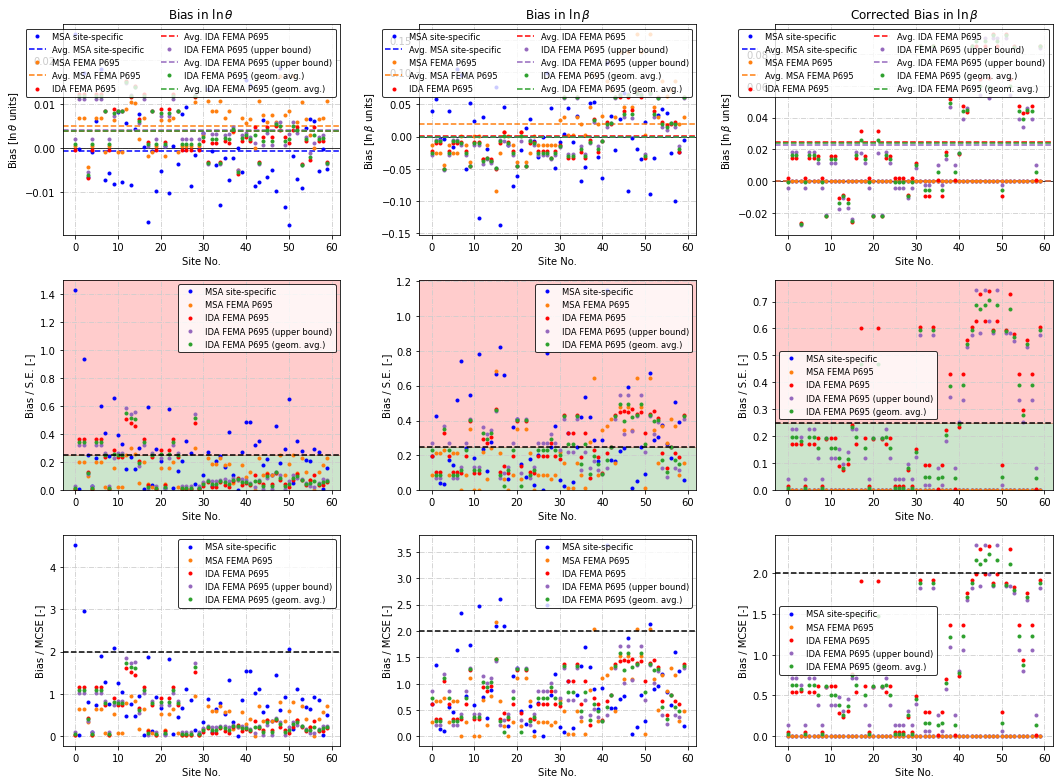

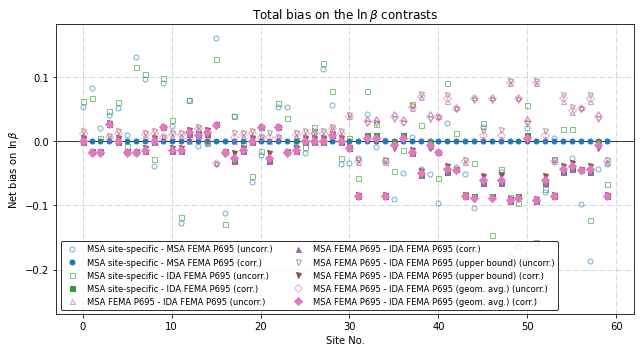

In [32]:
# With five arms the default all-pairs contrast set is larger than the figure can carry,
# so the comparisons that matter are named: the two MSA arms against each other, and each
# IDA bracket variant against the FEMAP695 MSA it is meant to reproduce.
BIAS_CONTRASTS = ([("site_msa", "msa_femap695"), ("site_msa", "ida_femap695"),
                   ("msa_femap695", "ida_femap695")]
                  + [("msa_femap695", BRACKET_ARM[v]) for v in BRACKET_VARIANTS])

for n in N_STOREYS:
    print(f"[{n}s]")
    fig1, axs1, fig2, axs2 = mra.plot_bias_assessment(bias_by_site[n],
                                                      refs_by_site[n],
                                                      contrasts=BIAS_CONTRASTS)


### 2.4 Save

Written through the same `bootstrap_csv_path` convention as the clouds, with the quantity
suffixed `_bias`, so the bias frames sit alongside the replicates they came from. The two
FEMAP695 arms are saved both ways; the site-specific arm has no groups.

In [33]:
# The arm and quantity keys are the same at every storey count, so the first one names
# what has to be written and the storey counts are gathered under it.
for _scope, _bias_by_n in [("by_site", bias_by_site), ("by_group", bias_by_group)]:
    for _arm, _quantities in _bias_by_n[N_STOREYS[0]].items():
        for _quantity in _quantities:
            _merged = mra.stack_unit_frames(
                {n: _bias_by_n[n][_arm][_quantity] for n in N_STOREYS})
            out = mra.bias_csv_path(BOOTSTRAP_PTH, _arm, _quantity, IM_TAG, _scope)
            _merged.to_csv(out)
            print(f"wrote {out.name}  {_merged.shape}")


wrote site_msa_bootstrap_theta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote site_msa_bootstrap_beta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote msa_femap695_bootstrap_theta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote msa_femap695_bootstrap_beta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote ida_femap695_bootstrap_theta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote ida_femap695_bootstrap_beta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote ida_femap695_ub_bootstrap_theta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote ida_femap695_ub_bootstrap_beta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote ida_femap695_avg_bootstrap_theta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote ida_femap695_avg_bootstrap_beta_bias_AvgSA_03_by_site.csv  (60, 11)
wrote msa_femap695_bootstrap_theta_bias_AvgSA_03_by_group.csv  (25, 11)
wrote msa_femap695_bootstrap_beta_bias_AvgSA_03_by_group.csv  (25, 11)
wrote ida_femap695_bootstrap_theta_bias_AvgSA_03_by_group.csv  (25, 11)
wrote ida_femap695_bootstrap_beta_bias_AvgSA_03_by_group.csv  (25, 11)
wro

wrote ida_femap695_ub_bootstrap_beta_bias_AvgSA_03_by_group.csv  (25, 11)
wrote ida_femap695_avg_bootstrap_theta_bias_AvgSA_03_by_group.csv  (25, 11)
wrote ida_femap695_avg_bootstrap_beta_bias_AvgSA_03_by_group.csv  (25, 11)
